In [9]:
%matplotlib inline

In [1]:
# Retrieve destrieux parcellation in fsaverage5 space from nilearn
from nilearn import datasets
import numpy as np

destrieux_atlas = datasets.fetch_atlas_surf_destrieux()

# The parcellation is already loaded into memory
parcellation = destrieux_atlas['map_left']

# Retrieve fsaverage5 surface dataset for the plotting background. It contains
# the surface template as pial and inflated version and a sulcal depth maps
# which is used for shading
fsaverage = datasets.fetch_surf_fsaverage()

# The fsaverage dataset contains file names pointing to the file locations
print("Fsaverage5 pial surface of left hemisphere is at: "
      f"{fsaverage['pial_left']}")
print("Fsaverage5 inflated surface of left hemisphere is at: "
      f"{fsaverage['infl_left']}")
print("Fsaverage5 sulcal depth map of left hemisphere is at: "
      f"{fsaverage['sulc_left']}")

Fsaverage5 pial surface of left hemisphere is at: /usr/local/lib/python3.9/site-packages/nilearn/datasets/data/fsaverage5/pial_left.gii.gz
Fsaverage5 inflated surface of left hemisphere is at: /usr/local/lib/python3.9/site-packages/nilearn/datasets/data/fsaverage5/infl_left.gii.gz
Fsaverage5 sulcal depth map of left hemisphere is at: /usr/local/lib/python3.9/site-packages/nilearn/datasets/data/fsaverage5/sulc_left.gii.gz


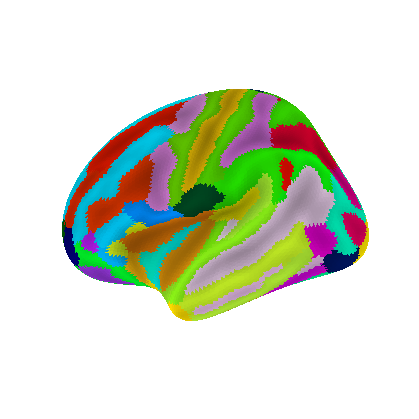

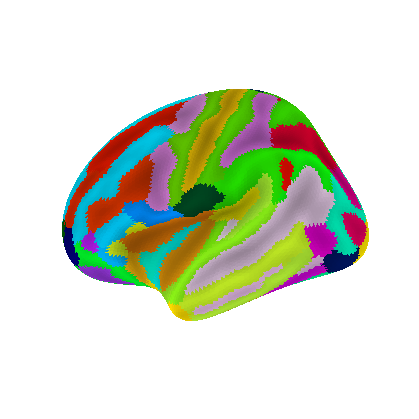

In [5]:
from nilearn import plotting

plotting.plot_surf_roi(fsaverage['infl_left'], roi_map=parcellation,
                       hemi='left', view='lateral',
                       bg_map=fsaverage['sulc_left'], bg_on_data=True,
                       darkness=.5)

/var/folders/rv/xy_78xhn26b1811ybdmcps1r0000gn/T/ipykernel_4379/2358801964.py:5: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  parcellation_random = np.zeros_like(parcellation, dtype=np.float)


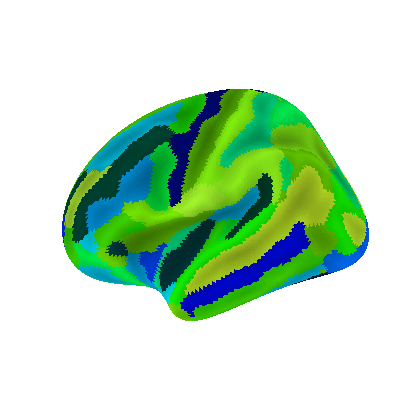

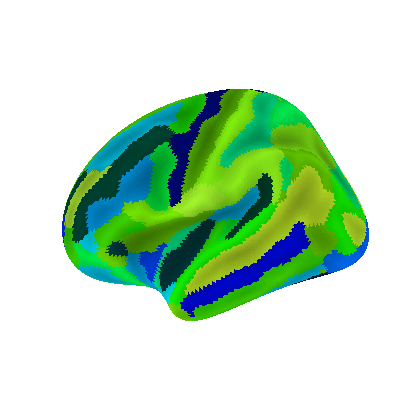

In [10]:
# Generate random numbers for each label
random_values = np.random.rand(len(np.unique(parcellation)))

# Replace the label values with random numbers
parcellation_random = np.zeros_like(parcellation, dtype=np.float)
unique_labels = np.unique(parcellation)
for i, label in enumerate(unique_labels):
    mask = parcellation == label
    parcellation_random[mask] = random_values[i]
    
plotting.plot_surf_roi(fsaverage['infl_left'], roi_map=parcellation_random,
                       hemi='left', view='lateral',
                       bg_map=fsaverage['sulc_left'], bg_on_data=True,
                       darkness=.5)

In [16]:
print(destrieux_atlas.description)

Destrieux Surface


Notes
-----
Anatomical parcellation of the cortex based on sulco-gyral patterns
(Destrieux et al, 2010) distributed with Freesurfer (Dale et al, 1999,
Fischl et al, 1999) in fsaverage5 standard surface space.

Content
-------
    :'annot_left': parcellation on left hemisphere in freesurfer annot format
    :'annot_right': parcellation on right hemisphere in freesurfer annot format


References
----------

Destrieux et al, (2010). Automatic parcellation of human cortical gyri and
sulci using standard anatomical nomenclature. NeuroImage 53.
http://dx.doi.org/10.1016/j.neuroimage.2010.06.010

Dale et al, (1999). Cortical surface-based analysis.I. Segmentation and
surface reconstruction. Neuroimage 9.
http://dx.doi.org/10.1006/nimg.1998.0395

Fischl et al, (1999). Cortical surface-based analysis. II: Inflation,
flattening, and a surface-based coordinate system. Neuroimage 9.
http://dx.doi.org/10.1006/nimg.1998.0396



/var/folders/rv/xy_78xhn26b1811ybdmcps1r0000gn/T/ipykernel_4379/11522582.py:4: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  parcellation_test = np.zeros_like(parcellation, dtype=np.float)


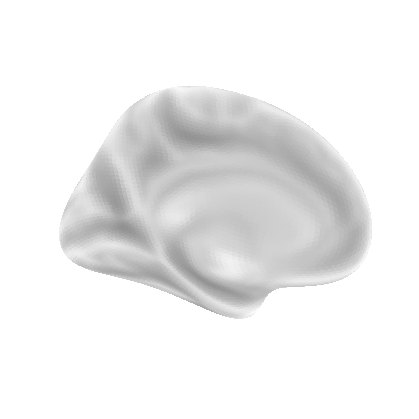

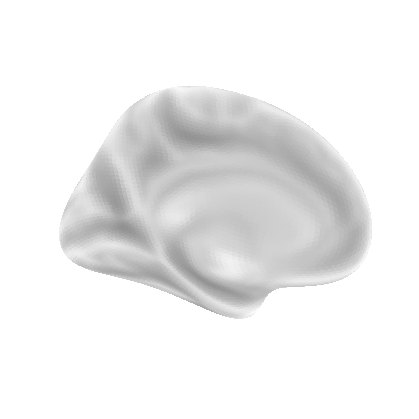

In [24]:
destrieux_atlas.labels.index(b'S_central')

# Replace the label values with random numbers
parcellation_test = np.zeros_like(parcellation, dtype=np.float)
parcellation_test[destrieux_atlas.labels.index(b'S_central')] = 1
    
plotting.plot_surf_roi(fsaverage['infl_left'], roi_map=parcellation_test,
                       hemi='left', view='lateral',
                       bg_map=fsaverage['sulc_left'], bg_on_data=True,
                       darkness=.5)